# Inspect a packaged SweepStim **gratings** NWB file

For the **passive drifting-gratings** (parametric-sweep) SweepStim path. Each
`stimulus_presentations` row is one grating sweep, carrying the stimulus parameters
resolved from the pkl `sweep_table` — `orientation`, `contrast`, `temporal_frequency`,
`spatial_frequency` — plus `condition_index` (row in `sweep_table`) and
`condition_repeat`.

For **natural-movie** sessions, use `inspect_sweepstim_nwb.ipynb` instead.

This notebook loads one packaged gratings session and validates: metadata & HED,
the parameter columns (levels, grid coverage, timing), an **independent re-derivation
of every parameter from the pkl**, `intervals`/epochs, running speed, and
cross-table consistency.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import pickle
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display

In [2]:
from hdmf_zarr.nwb import NWBZarrIO
import ndx_events   # noqa: F401 - registers NdxEventsNWBFile namespace
import ndx_hed      # noqa: F401 - registers HedTags / HedLabMetaData

# This notebook lives in code/sweepstim_packaging/; put the code dir on the path
# so `run_capsule` and the `sweepstim_packaging` package import cleanly.
CODE_DIR = Path.cwd()
if CODE_DIR.name == 'sweepstim_packaging':
    CODE_DIR = CODE_DIR.parent
sys.path.insert(0, str(CODE_DIR.resolve()))

from run_capsule import discover_sessions, find_sync, classify_session  # noqa: E402
from sweepstim_packaging import package_sweepstim_to_nwb                 # noqa: E402
from sweepstim_packaging.package import _is_grating_block               # noqa: E402

## Load a packaged gratings session

Packaged on demand to `/results/<sid>.nwb` and reused on re-runs.

In [3]:
DATA_DIR = Path('/data')
RESULTS_DIR = Path('/results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# This notebook is specific to passive SweepStim gratings sessions.
WANT = 'gratings'
KNOWN = {
    # drifting gratings, 2 stimulus blocks (contrast sweep + TF sweep)
    '1414269789': (
        '/data/multiplane-ophys_755252_2025-01-13_09-33-41/behavior/1414269789.pkl',
        '/data/multiplane-ophys_755252_2025-01-13_09-33-41/behavior/1414269789_20250113T093325.h5',
    ),
}
SID = '1414269789'   # -> another key above, or None to auto-discover a gratings session in /data


def _session_kind(pkl_data):
    """movie vs gratings, from whether any block is a parametric sweep."""
    stimuli = pkl_data.get('stimuli') or []
    if isinstance(stimuli, np.ndarray):
        stimuli = stimuli.tolist()
    return 'gratings' if any(_is_grating_block(s) for s in stimuli) else 'movie'


def resolve_session(sid):
    """Return (sid, pkl_path, sync_path) for a gratings SweepStim session."""
    if sid in KNOWN:
        pkl, sync = KNOWN[sid]
        return sid, Path(pkl), Path(sync)
    for cand_sid, pkl in sorted(discover_sessions(DATA_DIR).items()):
        if sid is not None and cand_sid != sid:
            continue
        with open(pkl, 'rb') as f:
            data = pickle.load(f, encoding='latin1')
        kind_cd, _ = classify_session(data)
        kind = _session_kind(data) if kind_cd == 'sweepstim' else None
        del data
        if kind == WANT:
            return cand_sid, pkl, find_sync(pkl, cand_sid)
    raise RuntimeError(f'No {WANT} SweepStim session found for SID={sid!r}')


SID, PKL_PATH, SYNC_PATH = resolve_session(SID)
NWB_PATH = RESULTS_DIR / f'{SID}.nwb'
if not NWB_PATH.exists():
    print(f'Packaging {SID} -> {NWB_PATH} ...')
    package_sweepstim_to_nwb(str(PKL_PATH), str(SYNC_PATH), str(NWB_PATH))
print(f'NWB: {NWB_PATH}')

Packaging 1414269789 -> /results/1414269789.nwb ...


INFO: SweepStim session detected: sweepstim-like structure: top-level stimuli list=True, items.foraging present=True


INFO: Adding SweepStim stimulus_presentations (1093 rows)


INFO: Adding SweepStim flat intervals table (5 epochs)


INFO: Adding running speed for SweepStim


INFO: Writing SweepStim NWB-Zarr to /results/1414269789.nwb


INFO: Wrote SweepStim sidecar JSON to /results/1414269789.events.json


NWB: /results/1414269789.nwb


In [4]:
io = NWBZarrIO(str(NWB_PATH), 'r', load_namespaces=True)
nwb = io.read()
print(f'Session description : {nwb.session_description}')
print(f'Session start time  : {nwb.session_start_time}')
print(f'Identifier          : {nwb.identifier}')
s = nwb.subject
print(f'Subject             : {s.subject_id}  species={s.species}  sex={s.sex}')
print(f'HED schema version  : {nwb.lab_meta_data["hed_schema"].hed_schema_version}')

Session description : STAGE_1
Session start time  : 2025-01-13 09:33:47.192000+00:00
Identifier          : 3b3b54a9-b884-40de-8e03-6ffc91bb82ef
Subject             : 755252  species=Mus musculus  sex=U
HED schema version  : 8.3.0


## NWB file structure

In [5]:
nwb

Name,/processing/running/dx/data
Type,zarr.core.Array
Data type,float32
Shape,"(224520,)"
Chunk shape,"(56130,)"
Order,C
Read-only,True
Compressor,"Blosc(cname='lz4', clevel=5, shuffle=SHUFFLE, blocksize=0)"
Store type,zarr.storage.ConsolidatedMetadataStore
Chunk store type,zarr.storage.DirectoryStore
No. bytes,898080 (877.0K)


In [6]:
def to_df(table, index_name=None):
    """NWB DynamicTable -> DataFrame with a typed index name."""
    df = table.to_dataframe()
    df.index.name = index_name or f'{table.name}_id'
    return df

## Stimulus presentations (grating sweeps)

One row per sweep. Confirms this is a grating session and summarizes the parameter levels and per-block design.

In [7]:
sp = to_df(nwb.intervals['stimulus_presentations'])
PARAM_COLS = [c for c in ('orientation', 'spatial_frequency', 'temporal_frequency',
                          'contrast', 'phase', 'position', 'size') if c in sp.columns]
assert PARAM_COLS, (
    'No grating parameter columns - this is not a grating session. '
    'Use inspect_sweepstim_nwb.ipynb for movie sessions.')
print(f'OK: grating session ({nwb.session_description}) with {len(sp)} presentations')
print('parameter columns:', PARAM_COLS)
print('columns:', list(sp.columns))

OK: grating session (STAGE_1) with 1093 presentations
parameter columns: ['orientation', 'spatial_frequency', 'temporal_frequency', 'contrast']
columns: ['start_time', 'stop_time', 'epoch_name', 'stim_type', 'stim_block', 'start_frame', 'stop_frame', 'orientation', 'spatial_frequency', 'temporal_frequency', 'contrast', 'condition_index', 'condition_repeat', 'HED']


In [8]:
print('stim_type(s):', list(sp['stim_type'].unique()))
print()
print('parameter levels (from the pkl sweep_table):')
for c in PARAM_COLS:
    vals = sorted(sp[c].dropna().unique())
    print(f'  {c:20s} {len(vals):2d} levels: {[float(v) for v in vals]}')
print()
print('per-block design:')
for b in sorted(sp['stim_block'].unique()):
    bl = sp[sp['stim_block'] == b]
    varying = [c for c in PARAM_COLS if bl[c].nunique() > 1]
    print(f'  block {b}  {bl["epoch_name"].iloc[0]:28s} '
          f'conditions={bl["condition_index"].nunique():3d}  '
          f'presentations={len(bl):4d}  varying={varying}')
sp.head()

stim_type(s): ['GratingStim']

parameter levels (from the pkl sweep_table):
  orientation           8 levels: [0.0, 45.0, 90.0, 135.0, 180.0, 225.0, 270.0, 315.0]
  spatial_frequency     1 levels: [0.04]
  temporal_frequency    5 levels: [1.0, 2.0, 4.0, 8.0, 15.0]
  contrast              5 levels: [0.05, 0.1, 0.2, 0.4, 0.8]

per-block design:
  block 0  drifting_gratings_contrast   conditions= 40  presentations= 546  varying=['orientation', 'contrast']
  block 1  drifting_gratings_TF         conditions= 40  presentations= 547  varying=['orientation', 'temporal_frequency']


,start_time,stop_time,epoch_name,stim_type,stim_block,start_frame,stop_frame,orientation,spatial_frequency,temporal_frequency,contrast,condition_index,condition_repeat,HED
stimulus_presentations_id,,,,,,,,,,,,,,
0,21.683686,23.685366,drifting_gratings_contrast,GratingStim,0,0,120,315.0,0.04,1.0,0.2,23,0,"Sensory-event, Visual-presentation, (Image, La..."
1,24.686206,26.687896,drifting_gratings_contrast,GratingStim,0,180,300,0.0,0.04,1.0,0.2,16,0,"Sensory-event, Visual-presentation, (Image, La..."
2,27.688736,29.690426,drifting_gratings_contrast,GratingStim,0,360,480,45.0,0.04,1.0,0.4,25,0,"Sensory-event, Visual-presentation, (Image, La..."
3,30.691276,32.692966,drifting_gratings_contrast,GratingStim,0,540,660,315.0,0.04,1.0,0.2,23,1,"Sensory-event, Visual-presentation, (Image, La..."
4,33.693806,35.695486,drifting_gratings_contrast,GratingStim,0,720,840,90.0,0.04,1.0,0.4,26,0,"Sensory-event, Visual-presentation, (Image, La..."


**Plot:** how often each parameter value was presented, and the orientation coverage on a polar axis. All levels should be well sampled.

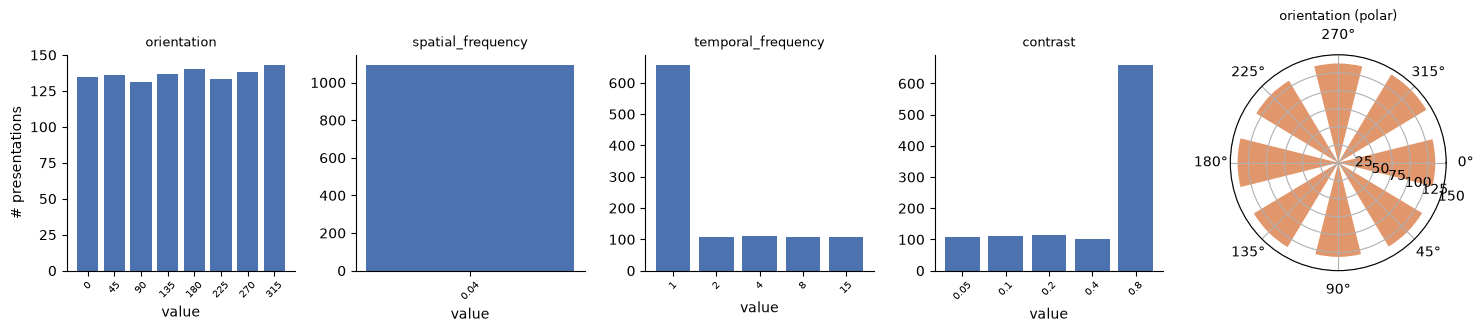

In [9]:
ncol = len(PARAM_COLS)
fig = plt.figure(figsize=(3*ncol + 3, 3.2))
for i, c in enumerate(PARAM_COLS):
    ax = fig.add_subplot(1, ncol + 1, i + 1)
    vc = sp[c].value_counts().sort_index()
    ax.bar(range(len(vc)), vc.values, color='#4C72B0')
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels([f'{v:g}' for v in vc.index], rotation=45, fontsize=7)
    ax.set_title(c, fontsize=9); ax.set_xlabel('value')
    if i == 0:
        ax.set_ylabel('# presentations')
    for s_ in ('top', 'right'):
        ax.spines[s_].set_visible(False)
if 'orientation' in sp.columns:
    axp = fig.add_subplot(1, ncol + 1, ncol + 1, projection='polar')
    oc = sp['orientation'].value_counts().sort_index()
    ang = np.deg2rad(oc.index.values.astype(float))
    axp.bar(ang, oc.values, width=np.deg2rad(28), color='#DD8452', alpha=0.85)
    axp.set_theta_zero_location('E'); axp.set_theta_direction(-1)
    axp.set_title('orientation (polar)', fontsize=9)
plt.tight_layout(); plt.show()

**Plot:** parameter-grid coverage per block. Each block sweeps two parameters; the heatmap counts presentations per grid cell — a valid sweep tiles the grid roughly evenly.

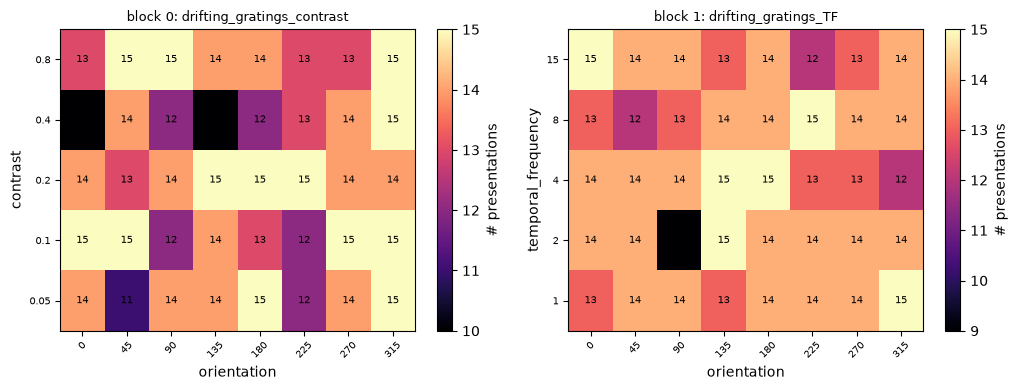

In [10]:
# Per block, count presentations for each cell of the 2-D parameter grid. A well
# formed sweep tiles the grid roughly evenly (each condition sampled ~equally).
stim_blocks = sorted(sp['stim_block'].unique())
fig, axes = plt.subplots(1, len(stim_blocks), figsize=(5.2*len(stim_blocks), 4), squeeze=False)
for ax, b in zip(axes[0], stim_blocks):
    bl = sp[sp['stim_block'] == b]
    varying = [c for c in PARAM_COLS if bl[c].nunique() > 1]
    if len(varying) >= 2:
        xcol, ycol = varying[0], varying[1]
        piv = bl.pivot_table(index=ycol, columns=xcol, values='start_time',
                             aggfunc='count', fill_value=0)
        im = ax.imshow(piv.values, aspect='auto', cmap='magma', origin='lower')
        ax.set_xticks(range(len(piv.columns)))
        ax.set_xticklabels([f'{v:g}' for v in piv.columns], rotation=45, fontsize=7)
        ax.set_yticks(range(len(piv.index)))
        ax.set_yticklabels([f'{v:g}' for v in piv.index], fontsize=7)
        ax.set_xlabel(xcol); ax.set_ylabel(ycol)
        for (yy, xx), v in np.ndenumerate(piv.values):
            ax.text(xx, yy, int(v), ha='center', va='center',
                    color='white' if v < piv.values.max()*0.6 else 'black', fontsize=7)
        plt.colorbar(im, ax=ax, label='# presentations')
    else:
        col = varying[0] if varying else 'condition_index'
        vc = bl[col].value_counts().sort_index()
        ax.bar(range(len(vc)), vc.values, color='#4C72B0'); ax.set_xlabel(col)
    ax.set_title(f'block {b}: {bl["epoch_name"].iloc[0]}', fontsize=9)
plt.tight_layout(); plt.show()

**Plot:** `condition_index` over time (colored by orientation) shows the shuffled sweep; the histogram confirms each grating is held ~2 s.

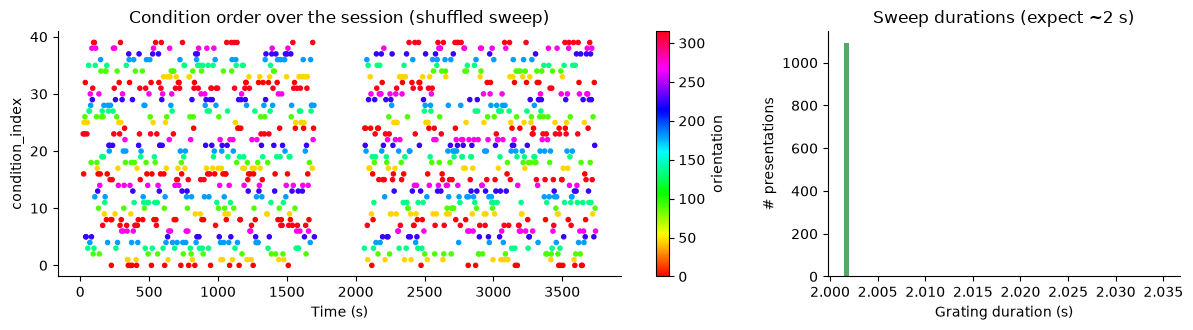

In [11]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 3.4), gridspec_kw={'width_ratios': [2, 1]})
ccol = 'orientation' if 'orientation' in sp.columns else PARAM_COLS[0]
sc = ax0.scatter(sp['start_time'], sp['condition_index'], c=sp[ccol], cmap='hsv', s=9)
ax0.set_xlabel('Time (s)'); ax0.set_ylabel('condition_index')
ax0.set_title('Condition order over the session (shuffled sweep)')
plt.colorbar(sc, ax=ax0, label=ccol)
dur = (sp['stop_time'] - sp['start_time']).values
ax1.hist(dur, bins=60, color='#55A868')
ax1.set_xlabel('Grating duration (s)'); ax1.set_ylabel('# presentations')
ax1.set_title('Sweep durations (expect ~2 s)')
for a in (ax0, ax1):
    for s_ in ('top', 'right'):
        a.spines[s_].set_visible(False)
plt.tight_layout(); plt.show()

## Ground-truth check against the pkl

Re-derive every presentation's parameters directly from the pkl `sweep_table` and confirm the packaged NWB matches exactly.

In [12]:
# Independent ground-truth check: re-derive each presentation's parameters straight
# from the pkl sweep_table (bypassing the packager) and confirm the NWB matches.
from sweepstim_packaging.package import _dimname_to_column, _as_sequence
with open(PKL_PATH, 'rb') as f:
    _pkl = pickle.load(f, encoding='latin1')
checked = mismatch = 0
for b in sorted(sp['stim_block'].unique()):
    stim = _pkl['stimuli'][b]
    dim = [_dimname_to_column(d) for d in _as_sequence(stim.get('dimnames'))]
    table = list(stim.get('sweep_table') or [])
    for _, r in sp[sp['stim_block'] == b].iterrows():
        params = dict(zip(dim, _as_sequence(table[int(r['condition_index'])])))
        for c in dim:
            if c in sp.columns:
                checked += 1
                mismatch += int(not np.isclose(float(params[c]), r[c], atol=1e-9))
print(f'Re-derived {checked} parameter values from the pkl sweep_table; mismatches vs NWB: {mismatch}')
assert mismatch == 0, 'NWB grating parameters do NOT match the pkl sweep_table!'
print('OK: every NWB grating parameter matches the pkl sweep_table.')

Re-derived 4372 parameter values from the pkl sweep_table; mismatches vs NWB: 0
OK: every NWB grating parameter matches the pkl sweep_table.


## Intervals (flat table) and epochs

Session-level `epoch` rows (grating blocks + `spontaneous` gaps) plus one `stimulus_presentation` row per sweep, linked by `stimulus_presentations_id`.

In [13]:
intervals = to_df(nwb.intervals['intervals'])
epochs = intervals[intervals['interval_type'] == 'epoch'].copy()
labels = list(dict.fromkeys(epochs['label']))
palette = plt.cm.tab20(np.linspace(0, 1, max(len(labels), 1)))
color_of = {lab: ('#cccccc' if lab == 'spontaneous' else palette[i % len(palette)])
            for i, lab in enumerate(labels)}
print(f'{len(intervals)} interval rows; {len(epochs)} epochs '
      f'({int((epochs.label!="spontaneous").sum())} stimulus, '
      f'{int((epochs.label=="spontaneous").sum())} spontaneous)')
epochs[['start_time', 'stop_time', 'label']].head(12)

1098 interval rows; 5 epochs (4 stimulus, 1 spontaneous)


,start_time,stop_time,label
intervals_id,,,
0,21.683686,862.411136,drifting_gratings_contrast
275,862.411136,1703.122096,drifting_gratings_TF
549,1703.122096,2063.426836,spontaneous
550,2063.426836,2904.137746,drifting_gratings_contrast
823,2904.137746,3744.882086,drifting_gratings_TF


**Plot:** grating blocks and spontaneous gaps tiling the session.

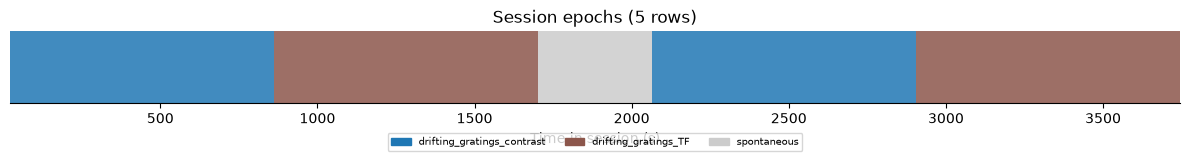

In [14]:
fig, ax = plt.subplots(figsize=(12, 2.0))
for _, ep in epochs.iterrows():
    ax.axvspan(ep['start_time'], ep['stop_time'],
               color=color_of[ep['label']], alpha=0.85, lw=0)
ax.set_xlim(float(epochs['start_time'].min()), float(epochs['stop_time'].max()))
ax.set_ylim(0, 1); ax.set_yticks([])
ax.set_xlabel('Time in session (s)')
ax.set_title(f'Session epochs ({len(epochs)} rows)')
uniq = list(dict.fromkeys(epochs['label']))[:12]
ax.legend(handles=[mpatches.Patch(color=color_of[l], label=l) for l in uniq],
          fontsize=7, ncol=6, loc='upper center', bbox_to_anchor=(0.5, -0.35))
for s_ in ('top', 'right', 'left'):
    ax.spines[s_].set_visible(False)
plt.tight_layout(); plt.show()

**Plot:** a short zoom showing individual ~2 s grating sweeps (separated by blank gaps).

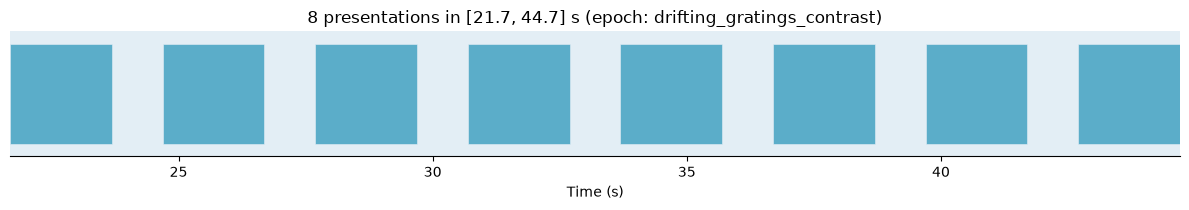

In [15]:
# Zoom to the first stimulus epoch; size the window so a few presentations show
# regardless of type (movie frames ~33 ms, gratings ~2 s).
stim_ep = epochs[epochs['label'] != 'spontaneous'].iloc[0]
in_ep = sp[(sp['start_time'] >= stim_ep['start_time'] - 1e-6)
           & (sp['start_time'] < stim_ep['stop_time'])]
t0 = float(in_ep['start_time'].iloc[0]) if len(in_ep) else float(stim_ep['start_time'])
first8 = sp[sp['start_time'] >= t0].head(8)
t1 = t0 + max(3.0, float(first8['stop_time'].max() - t0) if len(first8) else 3.0)

fig, ax = plt.subplots(figsize=(12, 2.2))
win = sp[(sp['start_time'] < t1) & (sp['stop_time'] > t0)]
for _, r in win.iterrows():
    ax.add_patch(plt.Rectangle((r['start_time'], 0.1),
                               max(r['stop_time'] - r['start_time'], 1e-4), 0.8,
                               color='#64B5CD', ec='white', lw=0.4))
ax.axvspan(t0, t1, color=color_of.get(stim_ep['label'], '#eee'), alpha=0.12, lw=0)
ax.set_xlim(t0, t1); ax.set_ylim(0, 1); ax.set_yticks([])
ax.set_xlabel('Time (s)')
ax.set_title(f'{len(win)} presentations in [{t0:.1f}, {t1:.1f}] s (epoch: {stim_ep["label"]})')
for s_ in ('top', 'right', 'left'):
    ax.spines[s_].set_visible(False)
plt.tight_layout(); plt.show()

## Running speed

Wheel speed from the SweepStim running path, plus the raw `dx` trace.

In [16]:
run = nwb.processing['running']
print('running module interfaces:', list(run.data_interfaces.keys()))
speed_ts = run['speed']
speed = np.asarray(speed_ts.data[:])
speed_t = np.asarray(speed_ts.timestamps[:])
print(f'\nspeed: n={speed.size}, unit={speed_ts.unit}, t=[{speed_t[0]:.2f}, {speed_t[-1]:.2f}] s')
print(f'  min={np.nanmin(speed):.2f}  median={np.nanmedian(speed):.2f}  '
      f'mean={np.nanmean(speed):.2f}  max={np.nanmax(speed):.2f} cm/s')

running module interfaces: ['dx', 'speed']

speed: n=224520, unit=cm/s, t=[21.65, 3766.85] s
  min=-4.65  median=0.12  mean=1.26  max=20.41 cm/s


**Plot:** full-session running speed with epoch backgrounds, plus its distribution.

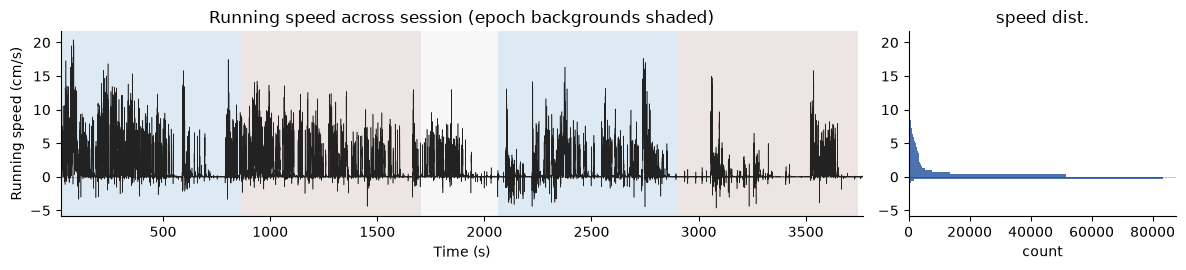

In [17]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 2.8), gridspec_kw={'width_ratios': [3, 1]})
for _, ep in epochs.iterrows():
    ax0.axvspan(ep['start_time'], ep['stop_time'], color=color_of[ep['label']], alpha=0.15, lw=0)
ax0.plot(speed_t, speed, color='#222222', lw=0.4)
ax0.axhline(0, color='k', lw=0.4, alpha=0.4)
ax0.set_xlim(speed_t[0], speed_t[-1])
ax0.set_xlabel('Time (s)'); ax0.set_ylabel('Running speed (cm/s)')
ax0.set_title('Running speed across session (epoch backgrounds shaded)')
ax1.hist(speed[np.isfinite(speed)], bins=80, color='#4C72B0', orientation='horizontal')
ax1.axhline(0, color='k', lw=0.4, alpha=0.4)
ax1.set_xlabel('count'); ax1.set_title('speed dist.')
for a in (ax0, ax1):
    for s_ in ('top', 'right'):
        a.spines[s_].set_visible(False)
plt.tight_layout(); plt.show()

**Plot:** the raw running-wheel `dx` trace (per-sample angular change).

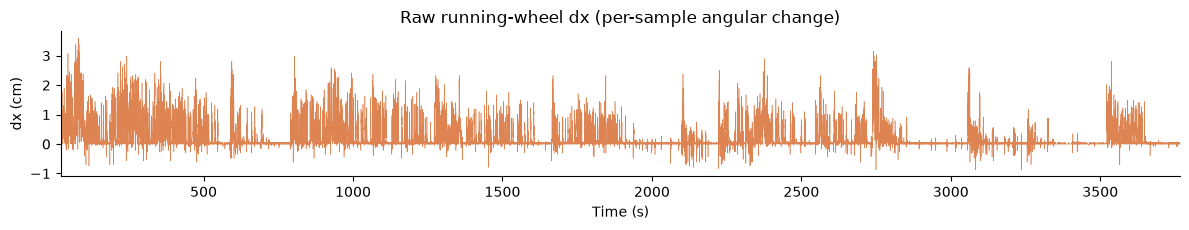

running span [21.6, 3766.8] s vs stimulus span [21.7, 3743.9] s


In [18]:
dx = np.asarray(run['dx'].data[:])
dx_t = np.asarray(run['dx'].timestamps[:])
fig, ax = plt.subplots(figsize=(12, 2.4))
ax.plot(dx_t, dx, color='#DD8452', lw=0.4)
ax.set_ylabel('dx (cm)'); ax.set_xlabel('Time (s)'); ax.set_xlim(dx_t[0], dx_t[-1])
ax.set_title('Raw running-wheel dx (per-sample angular change)')
for s_ in ('top', 'right'):
    ax.spines[s_].set_visible(False)
plt.tight_layout(); plt.show()
print(f'running span [{dx_t[0]:.1f}, {dx_t[-1]:.1f}] s vs '
      f'stimulus span [{sp["start_time"].min():.1f}, {sp["stop_time"].max():.1f}] s')

**Plot:** running speed zoomed to the same window as the sweep zoom, with sweep boundaries below — confirms the running and stimulus timebases line up.

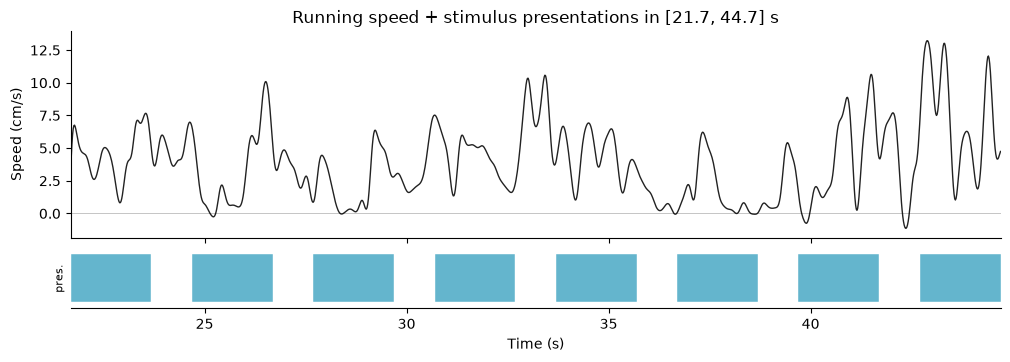

In [19]:
mask = (speed_t >= t0) & (speed_t <= t1)
fig, (ax_s, ax_e) = plt.subplots(2, 1, figsize=(12, 3.6), sharex=True,
                                 gridspec_kw={'height_ratios': [2.4, 0.7], 'hspace': 0.08})
ax_s.plot(speed_t[mask], speed[mask], color='#222222', lw=1.0)
ax_s.axhline(0, color='k', lw=0.4, alpha=0.4); ax_s.set_ylabel('Speed (cm/s)')
ax_s.set_title(f'Running speed + stimulus presentations in [{t0:.1f}, {t1:.1f}] s')
for _, r in win.iterrows():
    ax_e.add_patch(plt.Rectangle((r['start_time'], 0.1),
                                 max(r['stop_time'] - r['start_time'], 1e-4), 0.8,
                                 color='#64B5CD', ec='white', lw=0.3))
ax_e.set_xlim(t0, t1); ax_e.set_ylim(0, 1); ax_e.set_yticks([])
ax_e.set_ylabel('pres.', fontsize=8); ax_e.set_xlabel('Time (s)')
for s_ in ('top', 'right'):
    ax_s.spines[s_].set_visible(False)
for s_ in ('top', 'right', 'left'):
    ax_e.spines[s_].set_visible(False)
plt.tight_layout(); plt.show()

## Cross-table consistency checks

Grating-specific asserts: parameters fully populated, each `condition_index` maps to a single fixed parameter tuple, and no movie columns leaked in.

In [20]:
checks = []
iv_stim = intervals[intervals['interval_type'] == 'stimulus_presentation']
checks.append(('intervals stim rows == presentations', len(iv_stim) == len(sp)))
checks.append(('FK set == presentation index',
               set(iv_stim['stimulus_presentations_id']) == set(sp.index)))
checks.append(('start_time non-decreasing', bool(np.all(np.diff(sp['start_time'].values) >= 0))))
checks.append(('no stop_time <= start_time', bool(np.all((sp['stop_time'] - sp['start_time']).values > 0))))
for c in PARAM_COLS:
    checks.append((f'{c} populated for all presentations', bool(sp[c].notna().all())))
checks.append(('condition_index non-negative', bool((sp['condition_index'] >= 0).all())))
ok_const = True
for (b, ci), g in sp.groupby(['stim_block', 'condition_index']):
    if any(g[c].nunique() > 1 for c in PARAM_COLS):
        ok_const = False
        break
checks.append(('each condition_index has constant parameters', ok_const))
checks.append(('no movie columns leaked',
               not any(c in sp.columns for c in ['movie_frame_index', 'movie_repeat'])))
ss = sp.sort_values('start_time')
checks.append(('no temporal overlap between presentations',
               bool(np.all(ss['start_time'].values[1:] >= ss['stop_time'].values[:-1] - 1e-3))))
checks.append(('epochs tile without gaps/overlap',
               bool(np.allclose(epochs.sort_values('start_time')['start_time'].values[1:],
                                epochs.sort_values('start_time')['stop_time'].values[:-1]))))
for name, ok in checks:
    print(f'  {"OK " if ok else "XX "} {name}')
assert all(ok for _, ok in checks), 'One or more grating consistency checks FAILED'
print('\nAll grating consistency checks passed.')

  OK  intervals stim rows == presentations
  OK  FK set == presentation index
  OK  start_time non-decreasing
  OK  no stop_time <= start_time
  OK  orientation populated for all presentations
  OK  spatial_frequency populated for all presentations
  OK  temporal_frequency populated for all presentations
  OK  contrast populated for all presentations
  OK  condition_index non-negative
  OK  each condition_index has constant parameters
  OK  no movie columns leaked
  OK  no temporal overlap between presentations
  OK  epochs tile without gaps/overlap

All grating consistency checks passed.


## Sidecar JSON (`<sid>.events.json`)

The BIDS-style column dictionary written alongside the NWB.

In [21]:
sidecar_path = NWB_PATH.with_suffix('.events.json')
with open(sidecar_path) as f:
    sidecar = json.load(f)
print(f'{sidecar_path}  ({len(sidecar)} keys)')
print(json.dumps(sidecar, indent=2)[:2000])

/results/1414269789.events.json  (16 keys)
{
  "start_time": {
    "Description": "Frame or interval start time (s).",
    "HED": "Time-value/# s"
  },
  "stop_time": {
    "Description": "Frame or interval stop time (s).",
    "HED": "Time-value/# s"
  },
  "epoch_name": {
    "Description": "Epoch label: movie clip or grating stimulus name."
  },
  "stim_type": {
    "Description": "Stimulus class (e.g. GratingStim, ImageStimNumpyuByte)."
  },
  "stim_block": {
    "Description": "Stimulus block index from pkl top-level stimuli list.",
    "HED": "Label/stim_block-#"
  },
  "start_frame": {
    "Description": "Vsync frame at onset.",
    "HED": "Label/frame-#"
  },
  "stop_frame": {
    "Description": "Vsync frame at offset.",
    "HED": "Label/frame-#"
  },
  "orientation": {
    "Description": "Grating orientation (degrees).",
    "HED": "Label/orientation-#"
  },
  "spatial_frequency": {
    "Description": "Grating spatial frequency (cycles/degree).",
    "HED": "Label/spatial_fre

In [22]:
io.close()
print('Done - closed NWB file.')

Done - closed NWB file.
